In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [5]:
df = pd.read_csv('D:/Smartphone-Price-Prediction-Project/Smartphone-Price-Prediction-Project/data/processed/cleaned_smartphones.csv')

In [6]:
df.head()

,rating,Model,Price,Sim,5G,IrBlaster,NFC,Speed,Core,ProcessorName,...,Hz,Notches,RearCamera,RearMP,FrontMP,RearCameraCount,HasMemoryCard,IsHybrid,ExtraSupport,OS
0,89.0,oneplus 11,54999.0,1.0,1,0,1,3.2,8.0,snapdragon,...,120.0,punch hole,1.0,50.0,16.0,3.0,0.0,0.0,0.0,android
1,81.0,oneplus nord ce 2 lite,19989.0,1.0,1,0,0,2.2,8.0,snapdragon,...,120.0,punch hole,1.0,64.0,16.0,3.0,1.0,1.0,1024.0,android
2,75.0,samsung galaxy a14,16499.0,1.0,1,0,0,2.4,8.0,exynos,...,90.0,water drop notch,1.0,50.0,13.0,3.0,1.0,0.0,1024.0,android
3,81.0,motorola moto g62,14999.0,1.0,1,0,0,2.2,8.0,snapdragon,...,120.0,punch hole,1.0,50.0,16.0,3.0,1.0,1.0,1024.0,android
4,82.0,realme 10 pro plus,24999.0,1.0,1,0,0,2.6,8.0,dimensity,...,120.0,punch hole,1.0,108.0,16.0,3.0,0.0,0.0,0.0,android


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rating           879 non-null    float64
 1   Model            1020 non-null   object 
 2   Price            1020 non-null   float64
 3   Sim              1019 non-null   float64
 4   5G               1020 non-null   int64  
 5   IrBlaster        1020 non-null   int64  
 6   NFC              1020 non-null   int64  
 7   Speed            945 non-null    float64
 8   Core             980 non-null    float64
 9   ProcessorName    967 non-null    object 
 10  Ram              993 non-null    float64
 11  Rom              997 non-null    float64
 12  Capacity         987 non-null    float64
 13  Watt             769 non-null    float64
 14  FastCharging     1020 non-null   int64  
 15  Inches           987 non-null    float64
 16  Xaxis            987 non-null    float64
 17  Yaxis         

In [8]:
df.isna().sum()

rating             141
Model                0
Price                0
Sim                  1
5G                   0
IrBlaster            0
NFC                  0
Speed               75
Core                40
ProcessorName       53
Ram                 27
Rom                 23
Capacity            33
Watt               251
FastCharging         0
Inches              33
Xaxis               33
Yaxis               33
Hz                 409
Notches            135
RearCamera          62
RearMP              62
FrontMP             62
RearCameraCount     39
HasMemoryCard      279
IsHybrid           279
ExtraSupport       398
OS                 277
dtype: int64

In [ ]:
# Divide the data in X and y
X = df.drop(['Price', 'Model'], axis=1)
y = np.log1p(df['Price'])   # fixing right-skewed Price column data by log function

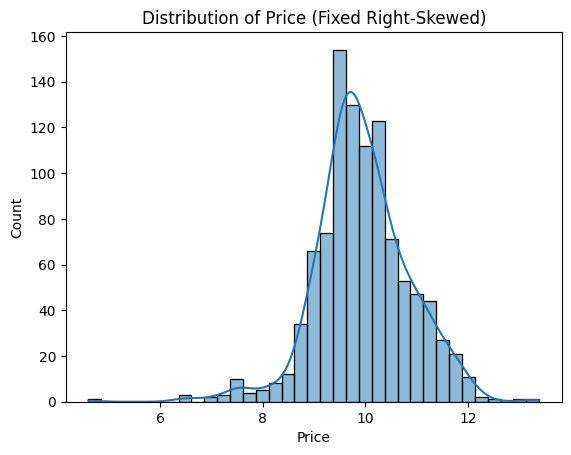

In [12]:
# Visualize the Price column after fixing right-skewed data
sns.histplot(data=df, x = y, kde=True, bins=35)

plt.title("Distribution of Price (Fixed Right-Skewed)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


In [33]:
# split the data into training and testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
print('X train shape:', X_train.shape)
print('y train shape:', y_train.shape)
print('X test shape:', X_test.shape)
print('y test shape:', y_test.shape) 

X train shape: (816, 26)
y train shape: (816,)
X test shape: (204, 26)
y test shape: (204,)


In [35]:
# Include all predictors (added 5G, NFC, Watt, FastCharging, IrBlaster)

numerical_column = ["rating", "Speed", "Core", "Ram", "Rom", "Capacity", "Inches",
                    "Xaxis", "Yaxis", "RearCamera", "RearMP", "FrontMP",
                    "RearCameraCount", "Sim", "Hz", "Watt"]

binary_and_constant = ["5G", "NFC", "IrBlaster", "FastCharging","HasMemoryCard",
                       "IsHybrid", "ExtraSupport"]

categorical_column = ["OS", "Notches", "ProcessorName"]


In [36]:
# Transformer 
# numerical transformer
numeric_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# constant transformer 
constant_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

categorical_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])


In [37]:
# Prepocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transform, numerical_column),
    ("const", constant_transform, binary_and_constant),
    ("cat", categorical_transform, categorical_column)
])

In [38]:
# Pipeline
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=150, random_state=42))
])

In [39]:
# fit model pipeline to training and testing data
model_pipeline.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('const', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [40]:
# y pred with log
y_pred_log = model_pipeline.predict(X_test)
y_pred_log

array([10.10672856, 10.00376044, 10.90974967,  9.92751557, 10.17986405,
       10.16987932,  9.68400018, 11.1681316 , 11.44169336,  9.74107921,
       10.94558253,  9.03287862, 10.05514971, 10.02110986, 10.68399575,
        7.7676947 , 11.22955434,  8.92637382,  9.51691799, 10.61823192,
        9.49284213,  9.08452783,  9.63538458,  9.45020681,  9.81205801,
        9.57600485, 10.82945952,  7.7676947 , 10.11259008, 10.20581951,
        8.23845776,  9.75080843,  9.04763583, 11.23224019, 10.49555951,
       10.54945713,  9.7322012 ,  9.28560654, 11.13254068,  9.13751677,
       11.52731947, 11.45538098, 10.11528364,  8.92834787,  9.34110681,
        9.53260782,  9.52567319, 10.74889413, 10.19258186,  9.69469912,
        9.48220212, 11.25877633,  9.49236763,  9.39572454, 10.50523203,
        9.82770536,  9.23844068, 10.08883149,  9.54155742,  9.77513724,
        9.41689647, 11.0797776 , 10.36279311, 10.78476431, 10.40375685,
        9.87822295, 10.09810287,  9.55935112,  9.54416511,  9.58

In [41]:
# Convert predictions back to actual Rupees
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

In [42]:
# Calculate R2 score and MAE
print(f"R2 Score(Log Scale): {r2_score(y_test, y_pred_log)*100:.4f}")
print(f"MAE(Actual Rupees): ₹{mean_absolute_error(y_test_actual, y_pred_actual):,.2f}")

R2 Score(Log Scale): 89.3054
MAE(Actual Rupees): ₹6,795.56
